# 1. Preparation

In [ ]:
import pandas as pd
import sys
sys.path.append('../../../')
from tqdm import tqdm
import json
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
from utilities import EarlyStopping, print_exams
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datetime import datetime
from bio_tokenizer import BioTokenizer
from utilities import print_exams
from transformers import MegaConfig, MegaForSequenceClassification
from MEGA_utilities import count_parameters

class HANADataset(Dataset):
    def __init__(self, DataFrame):
        self.sequence = (DataFrame['seq_a'] + '<eos>' + DataFrame['seq_b'] + '<eos>' + DataFrame['seq_c'] + '<eos>' + DataFrame['seq_d'] + \
                         '<eos>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat']).tolist()
        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequence[idx], self.labels[idx]


## Test HA_and_NA model in Crick data

In [16]:
test_data = pd.read_csv('./test_data.csv')
test_dataset = HANADataset(test_data)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')

In [17]:
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []

tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
device = torch.device('cuda:1')
model_HANA = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.2_HANA_model/2025-10-26_09-59-19.pth', weights_only=False, map_location=device)
model_HANA.eval()
for batch_seq, batch_label in test_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)
    with torch.no_grad():
        outputs = model_HANA(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()

HANA_Crick_df = test_data.copy()
HANA_Crick_df['prediction'] = prediction_ls_final

HANA_Crick_H1N1 = HANA_Crick_df[HANA_Crick_df['Type'] == 'H1N1']
HANA_Crick_H3N2 = HANA_Crick_df[HANA_Crick_df['Type'] == 'H3N2']
print_exams(reference_ls, prediction_ls_final)
print_exams(HANA_Crick_H1N1['label'], HANA_Crick_H1N1['prediction'])
print_exams(HANA_Crick_H3N2['label'], HANA_Crick_H3N2['prediction'])

MAE: 0.69425
MSE: 0.82469
pearson correlation: 0.88788
spearman correlation: 0.85274
R2_score: 0.73472
MAE: 0.67095
MSE: 0.74007
pearson correlation: 0.86890
spearman correlation: 0.69823
R2_score: 0.67391
MAE: 0.72126
MSE: 0.92276
pearson correlation: 0.85161
spearman correlation: 0.85444
R2_score: 0.63563


(0.7212614994691714,
 0.9227574396013837,
 PearsonRResult(statistic=0.8516085907969961, pvalue=0.0),
 SignificanceResult(statistic=0.8544416161674784, pvalue=0.0),
 0.6356257194894173)

## Test HA_and_NA data in CDC data

In [10]:
import pandas as pd

CDC_H1N1 = pd.read_excel('../../../data/raw/data4model(CDC-H1N1).xlsx')
CDC_H3N2 = pd.read_excel('../../../data/raw/data4model(CDC-H3N2).xlsx')
CDC_data = pd.concat([CDC_H1N1, CDC_H3N2])

In [20]:
# ## select required columns
# CDC_data_filt1 = CDC_data[['serumName','virusName','serumHA', 'serumNA', 'virusHA', 'virusNA', 
#                            'serumPassCat','virusPassCat', 'serumType','HI_Dist']].copy()
# ## remove duplicated row and mean HI_Dist
# CDC_data_filt2 = CDC_data_filt1.groupby(['serumHA', 'serumNA', 'virusHA', 'virusNA', 'serumPassCat', 'virusPassCat']) \
#         .agg({'serumName': 'first', 'virusName': 'first', 'serumType': 'first', 'HI_Dist': 'mean'}) \
#         .reset_index()[['serumName', 'virusName', 'serumHA', 'serumNA', 'virusHA', 'virusNA',
#                         'serumPassCat', 'virusPassCat', 'serumType', 'HI_Dist']]
# ## remove PassCat = 'BOTH'
# CDC_data_filt3 = CDC_data_filt2[(CDC_data_filt2['serumPassCat'] != 'BOTH') &
#                               (CDC_data_filt2['virusPassCat'] != 'BOTH')].reset_index(drop=True)
# ## replace PassCat to special token
# CDC_data_filt4 = CDC_data_filt3.replace({'serumPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'},
#                                        'virusPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'}})

# CDC_data_final = CDC_data_filt4.copy()

## select required columns
CDC_data_filt1 = CDC_data[['serumName','virusName','serumHA', 'serumNA', 'virusHA', 'virusNA', 
                           'serumPassCat','virusPassCat', 'serumType','HI_Dist']].copy()
## remove PassCat = 'BOTH'
CDC_data_filt2 = CDC_data_filt1[(CDC_data_filt1['serumPassCat'] != 'BOTH') &
                              (CDC_data_filt1['virusPassCat'] != 'BOTH')].reset_index(drop=True)
## replace PassCat to special token
CDC_data_filt3 = CDC_data_filt2.replace({'serumPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'},
                                         'virusPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'}})

CDC_data_final = CDC_data_filt3.copy()

In [25]:
CDC_HANA_dataset = HANADataset(CDC_data_final)
CDC_HANA_loader = DataLoader(CDC_HANA_dataset, batch_size=80, shuffle=False)

CDC_HA_dataset = HADataset(CDC_data_final)
CDC_HA_loader = DataLoader(CDC_HA_dataset, batch_size=80, shuffle=False)

In [28]:
from bio_tokenizer import BioTokenizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []

model_HANA.eval()
for batch_seq, batch_label in CDC_HANA_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)

    with torch.no_grad():
        outputs = model_HANA(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()


In [26]:
from bio_tokenizer import BioTokenizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []

model_HA.eval()
for batch_seq, batch_label in CDC_HA_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)

    with torch.no_grad():
        outputs = model_HA(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()


In [27]:
CDC_data = CDC_data_final.copy()
CDC_data['prediction'] = prediction_ls_final
CDC_data_H1N1 = CDC_data[CDC_data['serumType'] == 'H1N1']
CDC_data_H3N2 = CDC_data[CDC_data['serumType'] == 'H3N2']

print('CDC H1N1 r2_score:',r2_score(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 r2_score:',r2_score(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 MAE:',mean_absolute_error(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 MAE:',mean_absolute_error(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 MSE:',mean_squared_error(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 MSE:',mean_squared_error(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 Pearson:',pearsonr(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']).statistic)
print('CDC H3N2 Pearson:',pearsonr(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']).statistic)
print('CDC H1N1 Spearman:',spearmanr(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']).statistic)
print('CDC H3N2 Spearman:',spearmanr(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']).statistic)

CDC H1N1 r2_score: 0.72971156296519
CDC H3N2 r2_score: 0.12884351643802971
CDC H1N1 MAE: 0.8675767390375153
CDC H3N2 MAE: 1.4522670676778624
CDC H1N1 MSE: 1.2816716921944074
CDC H3N2 MSE: 3.318003889168995
CDC H1N1 Pearson: 0.8618641236521953
CDC H3N2 Pearson: 0.4311100254496784
CDC H1N1 Spearman: 0.5605352338320407
CDC H3N2 Spearman: 0.42719324948439574


In [29]:
CDC_data = CDC_data_final.copy()
CDC_data['prediction'] = prediction_ls_final
CDC_data_H1N1 = CDC_data[CDC_data['serumType'] == 'H1N1']
CDC_data_H3N2 = CDC_data[CDC_data['serumType'] == 'H3N2']

print('CDC H1N1 r2_score:',r2_score(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 r2_score:',r2_score(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 MAE:',mean_absolute_error(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 MAE:',mean_absolute_error(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 MSE:',mean_squared_error(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 MSE:',mean_squared_error(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 Pearson:',pearsonr(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']).statistic)
print('CDC H3N2 Pearson:',pearsonr(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']).statistic)
print('CDC H1N1 Spearman:',spearmanr(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']).statistic)
print('CDC H3N2 Spearman:',spearmanr(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']).statistic)

CDC H1N1 r2_score: 0.6637031394585429
CDC H3N2 r2_score: 0.24773626501635193
CDC H1N1 MAE: 0.9856082499276435
CDC H3N2 MAE: 1.3545357962685258
CDC H1N1 MSE: 1.5946748261166843
CDC H3N2 MSE: 2.8651729573897873
CDC H1N1 Pearson: 0.8207098352233697
CDC H3N2 Pearson: 0.5233500855290804
CDC H1N1 Spearman: 0.5517504042076447
CDC H3N2 Spearman: 0.5299750820354795


In [13]:
CDC_data = CDC_data_final.copy()
CDC_data['prediction'] = prediction_ls_final
CDC_data_H1N1 = CDC_data[CDC_data['serumType'] == 'H1N1']
CDC_data_H3N2 = CDC_data[CDC_data['serumType'] == 'H3N2']

print('CDC H1N1 r2_score:',r2_score(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 r2_score:',r2_score(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 MAE:',mean_absolute_error(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 MAE:',mean_absolute_error(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 MSE:',mean_squared_error(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']))
print('CDC H3N2 MSE:',mean_squared_error(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']))
print('CDC H1N1 Pearson:',pearsonr(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']).statistic)
print('CDC H3N2 Pearson:',pearsonr(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']).statistic)
print('CDC H1N1 Spearman:',spearmanr(CDC_data_H1N1['HI_Dist'], CDC_data_H1N1['prediction']).statistic)
print('CDC H3N2 Spearman:',spearmanr(CDC_data_H3N2['HI_Dist'], CDC_data_H3N2['prediction']).statistic)

CDC H1N1 r2_score: 0.6527285792317936
CDC H3N2 r2_score: 0.2337837247339536
CDC H1N1 MAE: 0.9837989084560332
CDC H3N2 MAE: 1.3375708969416742
CDC H1N1 MSE: 1.6128786861341684
CDC H3N2 MSE: 2.7774700665817855
CDC H1N1 Pearson: 0.8131703220788049
CDC H3N2 Pearson: 0.5178404792718588
CDC H1N1 Spearman: 0.5511339580082605
CDC H3N2 Spearman: 0.5221580910589687


## 4. Future test

In [13]:
test_data = pd.read_csv('../Crick_41_with_DNA.csv')
test_dataset = HANADataset(test_data)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [15]:
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
model_HANA = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.2_HANA_model/2025-10-26_09-59-19.pth', weights_only=False, map_location=device)
model_HANA.eval()
device = model_HANA.device
logits_ls = []
loss_ls_valid = []
prediction_ls = []
reference_ls = []
for batch_seq, batch_label in test_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)
    with torch.no_grad():
        outputs = model_HANA(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()

HANA_Crick_df = test_data.copy()
HANA_Crick_df['prediction'] = prediction_ls_final

HANA_Crick_H1N1 = HANA_Crick_df[HANA_Crick_df['Type'] == 'H1N1']
HANA_Crick_H3N2 = HANA_Crick_df[HANA_Crick_df['Type'] == 'H3N2']
print_exams(reference_ls, prediction_ls_final)
print_exams(HANA_Crick_H1N1['label'], HANA_Crick_H1N1['prediction'])
print_exams(HANA_Crick_H3N2['label'], HANA_Crick_H3N2['prediction'])

MAE: 0.71668
MSE: 0.82823
pearson correlation: 0.66064
spearman correlation: 0.67867
R2_score: -0.22310
MAE: 0.71901
MSE: 0.80677
pearson correlation: 0.46391
spearman correlation: 0.48890
R2_score: -0.83270
MAE: 0.71360
MSE: 0.85651
pearson correlation: 0.40804
spearman correlation: 0.39264
R2_score: -1.60926


(0.7136021279519833,
 0.8565113652153794,
 PearsonRResult(statistic=0.4080382573096464, pvalue=6.483026575055829e-43),
 SignificanceResult(statistic=0.39264484425398827, pvalue=1.3506237612980981e-39),
 -1.6092593501333878)

In [ ]:
# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
AA_model.eval()
for batch_seq, batch_label in AA_test_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)
    
    with torch.no_grad():
        outputs = AA_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()

AA_Crick_df = test_df.copy()
AA_Crick_df['prediction'] = prediction_ls_final

AA_Crick_H1N1 = AA_Crick_df[AA_Crick_df['Type'] == 'H1N1']
AA_Crick_H3N2 = AA_Crick_df[AA_Crick_df['Type'] == 'H3N2']
## All
print_exams(reference_ls, prediction_ls_final)
## H1N1
print_exams(AA_Crick_H1N1['label'], AA_Crick_H1N1['prediction'])
## H3N2
print_exams(AA_Crick_H3N2['label'], AA_Crick_H3N2['prediction'])

MAE: 0.75578
MSE: 0.91008
pearson correlation: 0.66406
spearman correlation: 0.66804
R2_score: 0.24345
MAE: 0.72133
MSE: 0.81495
pearson correlation: 0.37505
spearman correlation: 0.41822
R2_score: -0.77518
MAE: 0.80117
MSE: 1.03545
pearson correlation: 0.47301
spearman correlation: 0.49293
R2_score: -0.15531


(0.8011729661022893,
 1.0354458095484997,
 PearsonRResult(statistic=0.47301035899622573, pvalue=5.519841028768764e-59),
 SignificanceResult(statistic=0.4929271880562811, pvalue=1.198163402842232e-64),
 -0.1553085049166516)

# 4. Visualization

In [17]:
HA_H1N1_result = print_exams(HA_df.loc[HA_df['serumType'] == 'H1N1','prediction'], 
HA_df.loc[HA_df['serumType'] == 'H1N1', 'HI_Dist'], print_result=False)
HA_H3N2_result = print_exams(HA_df.loc[HA_df['serumType'] == 'H3N2','prediction'], 
HA_df.loc[HA_df['serumType'] == 'H3N2', 'HI_Dist'], print_result=False)
HANA_H1N1_result = print_exams(HANA_df.loc[HANA_df['serumType'] == 'H1N1','prediction'], 
HANA_df.loc[HANA_df['serumType'] == 'H1N1', 'HI_Dist'], print_result=False)
HANA_H3N2_result = print_exams(HANA_df.loc[HANA_df['serumType'] == 'H3N2','prediction'], 
HANA_df.loc[HANA_df['serumType'] == 'H3N2', 'HI_Dist'], print_result=False)

In [20]:
df

,model,H1_MAE,H1_Pearson,H3_MAE,H3_Pearson
0,AA,1.099321,0.550223,1.631155,0.341286
1,DNA,0.739787,0.837836,1.006954,0.707552


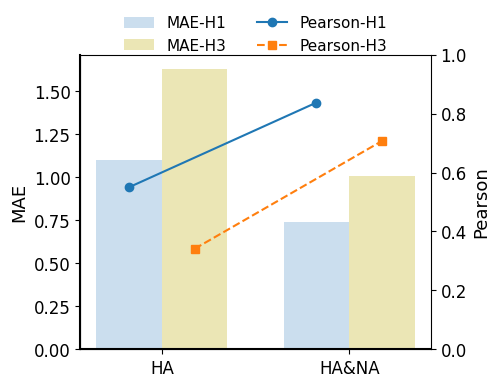

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 示例数据
df = pd.DataFrame({
    'model': ['HA', 'HA&NA'],
    'H1_MAE': [HA_H1N1_result[0], HANA_H1N1_result[0]],
    'H1_Pearson': [HA_H1N1_result[2][0], HANA_H1N1_result[2][0]],
    'H3_MAE': [HA_H3N2_result[0], HANA_H3N2_result[0]],
    'H3_Pearson': [HA_H3N2_result[2][0], HANA_H3N2_result[2][0]]
})

# X 轴位置
x = np.arange(len(df['model']))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 4))

# --- 并列两根 MAE 柱 ---
bar1 = ax.bar(x - width/2, df['H1_MAE'], width, label='MAE-H1', color="#CBDEEE")
bar2 = ax.bar(x + width/2, df['H3_MAE'], width, label='MAE-H3', color="#EBE6B5")

# 美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set_ylabel('MAE', fontsize=13)
ax.set_xlabel('')
ax.set_xticks(x)
ax.set_xticklabels(df['model'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# --- 折线图，两条 ---
ax2 = ax.twinx()

# 对齐到柱中心的 x 坐标
h1_x = x - width/2
h3_x = x + width/2

# H1 Pearson
ax2.plot(h1_x, df['H1_Pearson'], label='Pearson-H1',
         marker='o', linestyle='-', linewidth=1.5)

# H3 Pearson
ax2.plot(h3_x, df['H3_Pearson'], label='Pearson-H3',
         marker='s', linestyle='--', linewidth=1.5)

ax2.set_ylabel("Pearson", fontsize=13, color='black')
ax2.tick_params(axis='y', labelsize=12, colors='black')
ax2.set_ylim(0, 1)

# 合并 legend（主轴 + 副轴）
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2,
          frameon=False, fontsize=11, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.18))


plt.tight_layout()
plt.savefig("Figure_S1a.svg", dpi=300, transparent=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 示例数据
df = pd.DataFrame({
    'model': ['AA', 'DNA'],
    'H1_MAE': [AA_H1N1_result[0], DNA_H1N1_result[0]],
    'H3_MAE': [AA_H3N2_result[0], DNA_H3N2_result[0]],
    'H1_Pearson': [AA_H1N1_result[2][0], DNA_H1N1_result[2][0]],
    'H3_Pearson': [AA_H3N2_result[2][0], DNA_H3N2_result[2][0]]
})

# X 轴位置
x = np.arange(len(df['model']))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 4))

# --- 并列两根 MAE 柱 ---
bar1 = ax.bar(x - width/2, df['H1_MAE'], width, label='MAE-H1', color="#CBDEEE")
bar2 = ax.bar(x + width/2, df['H3_MAE'], width, label='MAE-H3', color="#EBE6B5")

# 美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set_ylabel('MAE', fontsize=13)
ax.set_xlabel('')
ax.set_xticks(x)
ax.set_xticklabels(df['model'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# --- 折线图，两条 ---
ax2 = ax.twinx()

# 对齐到柱中心的 x 坐标
h1_x = x - width/2
h3_x = x + width/2

# H1 Pearson
ax2.plot(h1_x, df['H1_Pearson'], label='Pearson-H1',
         marker='o', linestyle='-', linewidth=1.5)

# H3 Pearson
ax2.plot(h3_x, df['H3_Pearson'], label='Pearson-H3',
         marker='s', linestyle='--', linewidth=1.5)

ax2.set_ylabel("Pearson", fontsize=13, color='black')
ax2.tick_params(axis='y', labelsize=12, colors='black')
ax2.set_ylim(0, 1)

# 合并 legend（主轴 + 副轴）
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2,
          frameon=False, fontsize=11, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.18))


plt.tight_layout()
plt.savefig("Figure_S1a.svg", dpi=300, transparent=True)

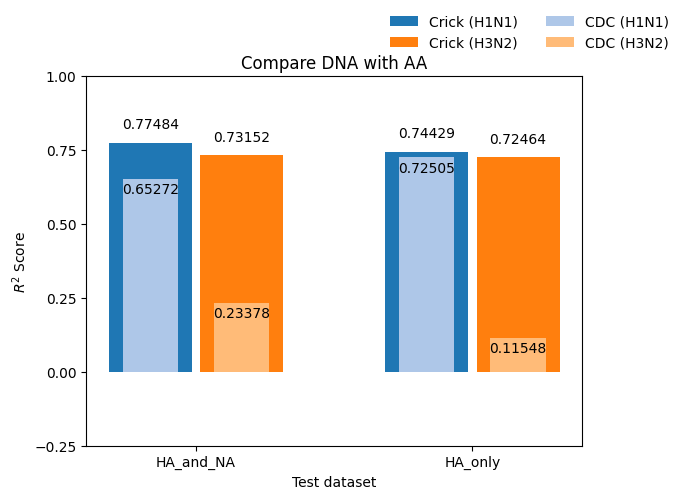

: 

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
samples = ['HA_and_NA', 'HA_only']
datasets = ['Crick', 'CDC']
# AA and DNA use R2 score to evaluate the model

H1_data = {
    'Crick': [0.77484, 0.74429],
    'CDC': [0.65272, 0.72505]
}
H3_data = {
    'Crick': [0.73152, 0.72464],
    'CDC': [0.23378, 0.11548]
}

# 设置柱状图的位置
x = np.arange(len(samples))

# 创建图形和轴
fig, ax = plt.subplots()

# 绘制每个波长的柱状图
colors_H1 = ['#1f77b4', '#aec7e8']  # 深蓝色和浅蓝色
colors_H3 = ['#ff7f0e', '#ffbb78']  # 橙色和浅橙色
widths = [0.3, 0.2]  # 设置每个柱子的宽度
dataset_drift = [0.05, -0.05]
for i, dataset in enumerate(datasets):
    ax.bar(x - widths[0]*1.1/2, H1_data[dataset], width=widths[i], label=dataset + ' (H1N1)', color=colors_H1[i], capsize=5)
    ax.text(x[0] - widths[0]*1.1/2, H1_data[dataset][0] + dataset_drift[i], str(H1_data[dataset][0]), ha='center')
    ax.text(x[1] - widths[0]*1.1/2, H1_data[dataset][1] + dataset_drift[i], str(H1_data[dataset][1]), ha='center')
    ax.bar(x + widths[0]*1.1/2, H3_data[dataset], width=widths[i], label=dataset + ' (H3N2)', color=colors_H3[i], capsize=5)
    ax.text(x[0] + widths[0]*1.1/2, H3_data[dataset][0] + dataset_drift[i], str(H3_data[dataset][0]), ha='center')
    ax.text(x[1] + widths[0]*1.1/2, H3_data[dataset][1] + dataset_drift[i], str(H3_data[dataset][1]), ha='center')



# 设置标签和标题
ax.set_xlabel('Test dataset')
ax.set_ylabel(r'$R^2$ Score')
ax.set_title('Compare protein selection')
ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_yticks(np.arange(-0.25, 1.25, 0.25))
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2), frameon=False, ncol=2)


# 显示图形
plt.savefig('1.2_test.png', dpi=300, bbox_inches='tight')